# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Gema Vizayaksa
- **Email:** cdcc452d6y1055@student.devacademy.id
- **ID Dicoding:** gema_vizayaksa

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Pada periode 2011–2012, musim dan kondisi cuaca mana yang menghasilkan rata-rata jumlah penyewaan sepeda harian tertinggi dan terendah, sehingga perusahaan dapat menentukan waktu terbaik untuk promosi dan pengelolaan armada?
- **Pertanyaan 2:** Pada periode 2011–2012, pada jam berapa permintaan penyewaan sepeda paling tinggi pada hari kerja dan hari non-kerja, sehingga perusahaan dapat mengatur distribusi sepeda berdasarkan pola waktu penggunaan?
- ...

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")
os.makedirs("dashboard", exist_ok=True)
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Pada tahap ini, dataset harian dan dataset per jam dimuat ke dalam DataFrame. Dataset harian digunakan untuk menganalisis tren berdasarkan musim dan cuaca, sedangkan dataset per jam digunakan untuk menganalisis pola penggunaan berdasarkan jam.

### Assessing Data

#### Identifying ... problem

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
print("Jumlah duplikasi day_df:", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df:", hour_df.duplicated().sum())

Jumlah duplikasi day_df: 0
Jumlah duplikasi hour_df: 0


In [ ]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [ ]:
print("Nilai unik season:", day_df["season"].unique())
print("Nilai unik yr:", day_df["yr"].unique())
print("Nilai unik mnth:", day_df["mnth"].unique())
print("Nilai unik holiday:", day_df["holiday"].unique())
print("Nilai unik weekday:", day_df["weekday"].unique())
print("Nilai unik workingday:", day_df["workingday"].unique())
print("Nilai unik weathersit:", day_df["weathersit"].unique())

Nilai unik season: [1 2 3 4]
Nilai unik yr: [0 1]
Nilai unik mnth: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Nilai unik holiday: [0 1]
Nilai unik weekday: [6 0 1 2 3 4 5]
Nilai unik workingday: [0 1]
Nilai unik weathersit: [2 1 3]


In [ ]:
print("Nilai unik hr:", hour_df["hr"].unique())
print("Nilai unik weathersit:", hour_df["weathersit"].unique())

Nilai unik hr: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Nilai unik weathersit: [1 2 3 4]


In [ ]:
def count_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    return len(outliers), lower_limit, upper_limit

for col in ["cnt", "casual", "registered", "hum", "windspeed"]:
    total_outlier, lower, upper = count_outliers(day_df, col)
    print(f"{col}: {total_outlier} outlier, batas bawah={lower:.2f}, batas atas={upper:.2f}")

cnt: 0 outlier, batas bawah=-1054.00, batas atas=10162.00
casual: 44 outlier, batas bawah=-855.25, batas atas=2266.75
registered: 0 outlier, batas bawah=-922.25, batas atas=8195.75
hum: 2 outlier, batas bawah=0.20, batas atas=1.05
windspeed: 13 outlier, batas bawah=-0.01, batas atas=0.38


**Steps to Take:**
- Cek informasi data
- Cek missing value
- Cek duplikasi
- Cek statistik
- Cek invalid value pada kolom kategori
- Cek outlier sederhana menggunakan IQR

**Insight:** (Opsional)
- Kolom `dteday` masih bertipe object, sehingga perlu diubah menjadi datetime.
- Beberapa kolom kategori seperti `season`, `yr`, `mnth`, `weekday`, `workingday`, dan `weathersit` masih berbentuk angka. Agar analisis lebih mudah dipahami, kolom-kolom tersebut perlu diberi label deskriptif.
- Tidak ditemukan missing value pada dataset.
- Tidak ditemukan data duplikat pada dataset.
- Terdapat indikasi outlier pada beberapa kolom seperti `casual`, `hum`, dan `windspeed`. Namun, outlier tersebut tidak langsung dihapus karena masih bisa merepresentasikan kondisi nyata, seperti hari dengan lonjakan pengguna kasual atau cuaca ekstrem.


### Cleaning Data

#### Fixing ... problem

In [ ]:
# Mengubah kolom tanggal menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

In [ ]:
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

weather_map = {
    1: "Clear/Partly Cloudy",
    2: "Mist/Cloudy",
    3: "Light Snow/Rain",
    4: "Heavy Rain/Snow"
}

year_map = {
    0: "2011",
    1: "2012"
}

workingday_map = {
    0: "Non-working Day",
    1: "Working Day"
}

weekday_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

In [ ]:
day_df["season_name"] = day_df["season"].map(season_map)
day_df["weather_name"] = day_df["weathersit"].map(weather_map)
day_df["year"] = day_df["yr"].map(year_map)
day_df["workingday_name"] = day_df["workingday"].map(workingday_map)
day_df["weekday_name"] = day_df["weekday"].map(weekday_map)

hour_df["season_name"] = hour_df["season"].map(season_map)
hour_df["weather_name"] = hour_df["weathersit"].map(weather_map)
hour_df["year"] = hour_df["yr"].map(year_map)
hour_df["workingday_name"] = hour_df["workingday"].map(workingday_map)
hour_df["weekday_name"] = hour_df["weekday"].map(weekday_map)

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   instant          731 non-null    int64         
 1   dteday           731 non-null    datetime64[ns]
 2   season           731 non-null    int64         
 3   yr               731 non-null    int64         
 4   mnth             731 non-null    int64         
 5   holiday          731 non-null    int64         
 6   weekday          731 non-null    int64         
 7   workingday       731 non-null    int64         
 8   weathersit       731 non-null    int64         
 9   temp             731 non-null    float64       
 10  atemp            731 non-null    float64       
 11  hum              731 non-null    float64       
 12  windspeed        731 non-null    float64       
 13  casual           731 non-null    int64         
 14  registered       731 non-null    int64    

In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   instant          17379 non-null  int64         
 1   dteday           17379 non-null  datetime64[ns]
 2   season           17379 non-null  int64         
 3   yr               17379 non-null  int64         
 4   mnth             17379 non-null  int64         
 5   hr               17379 non-null  int64         
 6   holiday          17379 non-null  int64         
 7   weekday          17379 non-null  int64         
 8   workingday       17379 non-null  int64         
 9   weathersit       17379 non-null  int64         
 10  temp             17379 non-null  float64       
 11  atemp            17379 non-null  float64       
 12  hum              17379 non-null  float64       
 13  windspeed        17379 non-null  float64       
 14  casual           17379 non-null  int64

In [ ]:
hour_df.to_csv("dashboard/main_data.csv", index=False)

**Insight:** (Opsional)
- Pada tahap cleaning, kolom `dteday` diubah menjadi datetime. Selain itu, beberapa kolom kategori yang sebelumnya berbentuk angka diberi label deskriptif agar lebih mudah digunakan dalam visualisasi dan dashboard.

## Exploratory Data Analysis (EDA)

Pada bagian ini, dilakukan eksplorasi untuk:

- Mengetahui rata-rata jumlah penyewaan sepeda berdasarkan musim (season).
- Mengetahui total penyewaan pada tiap musim.
- Membandingkan penyewaan antara pengguna casual dan registered.
- Menganalisis pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda.

In [ ]:
#pertanyaan bisnis 1
#Analisis rata-rata penyewaan berdasarkan musim:
season_analysis = day_df.groupby("season_name").agg({
    "cnt": ["mean", "sum"],
    "casual": "mean",
    "registered": "mean"
}).round(2)

season_analysis

cnt            casual registered
                mean      sum     mean       mean
season_name                                      
Fall         5644.30  1061129  1202.61    4441.69
Spring       2604.13   471348   334.93    2269.20
Summer       4992.33   918589  1106.10    3886.23
Winter       4728.16   841613   729.11    3999.05

In [ ]:
#Analisis rata-rata penyewaan berdasarkan cuaca:
weather_analysis = day_df.groupby("weather_name").agg({
    "cnt": ["mean", "sum", "count"]
}).round(2)

weather_analysis

cnt               
                        mean      sum count
weather_name                               
Clear/Partly Cloudy  4876.79  2257952   463
Light Snow/Rain      1803.29    37869    21
Mist/Cloudy          4035.86   996858   247

In [ ]:
#pertanyaan bisnis 2
#Analisis rata-rata penyewaan berdasarkan jam dan tipe hari:
hourly_analysis = hour_df.groupby(["workingday_name", "hr"]).agg({
    "cnt": "mean"
}).reset_index()

hourly_analysis.head()

,workingday_name,hr,cnt
0,Non-working Day,0,90.800000
1,Non-working Day,1,69.508696
2,Non-working Day,2,53.171053
3,Non-working Day,3,25.775330
4,Non-working Day,4,8.264317


In [ ]:
#Cari jam tersibuk:
hourly_analysis.sort_values("cnt", ascending=False).head(10)

,workingday_name,hr,cnt
41,Working Day,17,525.290581
42,Working Day,18,492.226908
32,Working Day,8,477.006048
13,Non-working Day,13,372.731602
12,Non-working Day,12,366.259740
14,Non-working Day,14,364.645022
15,Non-working Day,15,358.813853
16,Non-working Day,16,352.727273
43,Working Day,19,348.401606
17,Non-working Day,17,323.549784


**Insight:** (Opsional)
- Berdasarkan dataset, hasil intinya (pertanyaan bisnis 1):

Rata-rata penyewaan harian tertinggi berdasarkan musim:
Fall    ≈ 5.644 penyewaan/hari

Rata-rata penyewaan harian terendah berdasarkan musim:
Spring  ≈ 2.604 penyewaan/hari

Rata-rata penyewaan harian tertinggi berdasarkan cuaca:
Clear/Partly Cloudy ≈ 4.877 penyewaan/hari

Rata-rata penyewaan harian terendah berdasarkan cuaca:
Light Snow/Rain ≈ 1.803 penyewaan/hari
- Berdasarkan dataset, hasil intinya (Pertanyaan bisnis 2):

Hari kerja:
Jam tersibuk adalah sekitar pukul 17.00, 18.00, dan 08.00.

Hari non-kerja:
Jam tersibuk cenderung terjadi pada siang hingga sore hari, sekitar pukul 12.00–16.00.
- Interpretasi awal, Pada hari kerja, pola penyewaan menunjukkan karakteristik commuting, yaitu tinggi pada pagi hari saat berangkat kerja dan sore hari saat pulang kerja. Pada hari non-kerja, penyewaan lebih tersebar pada siang hingga sore hari, yang kemungkinan lebih berkaitan dengan aktivitas rekreasi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

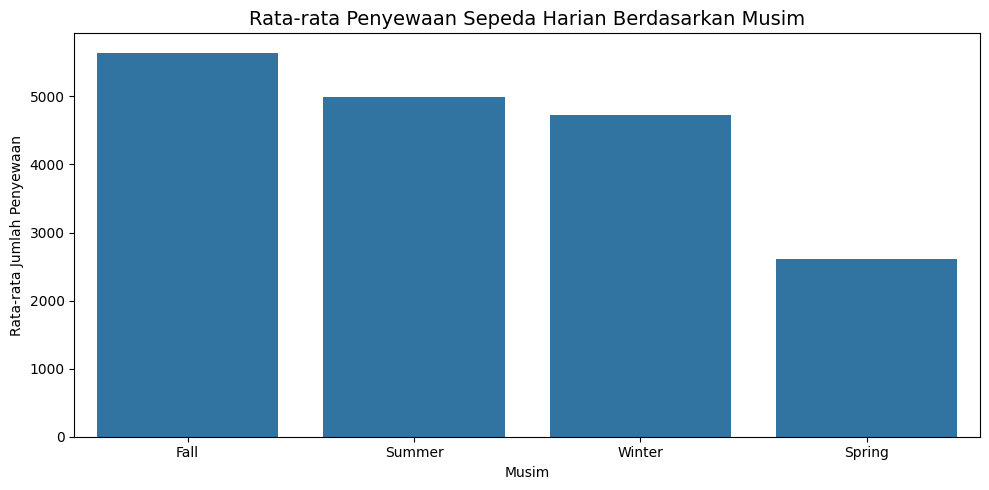

In [ ]:
#Visualisasi Rata-rata Penyewaan Berdasarkan Musim
plt.figure(figsize=(10, 5))

season_order = day_df.groupby("season_name")["cnt"].mean().sort_values(ascending=False).index

sns.barplot(
    data=day_df,
    x="season_name",
    y="cnt",
    order=season_order,
    estimator=np.mean,
    errorbar=None
)

plt.title("Rata-rata Penyewaan Sepeda Harian Berdasarkan Musim", fontsize=14)
plt.xlabel("Musim")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.tight_layout()
plt.show()

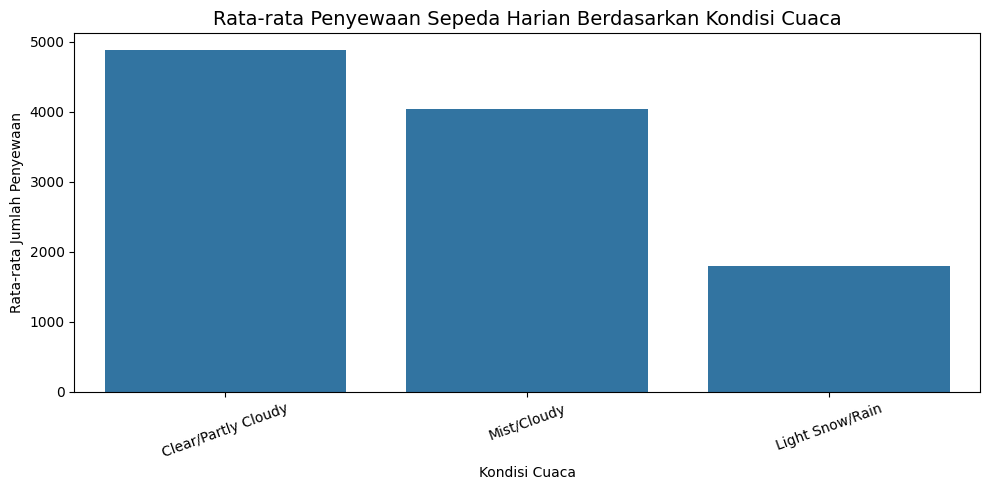

In [ ]:
#visualisasi cuaca
plt.figure(figsize=(10, 5))

weather_order = day_df.groupby("weather_name")["cnt"].mean().sort_values(ascending=False).index

sns.barplot(
    data=day_df,
    x="weather_name",
    y="cnt",
    order=weather_order,
    estimator=np.mean,
    errorbar=None
)

plt.title("Rata-rata Penyewaan Sepeda Harian Berdasarkan Kondisi Cuaca", fontsize=14)
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

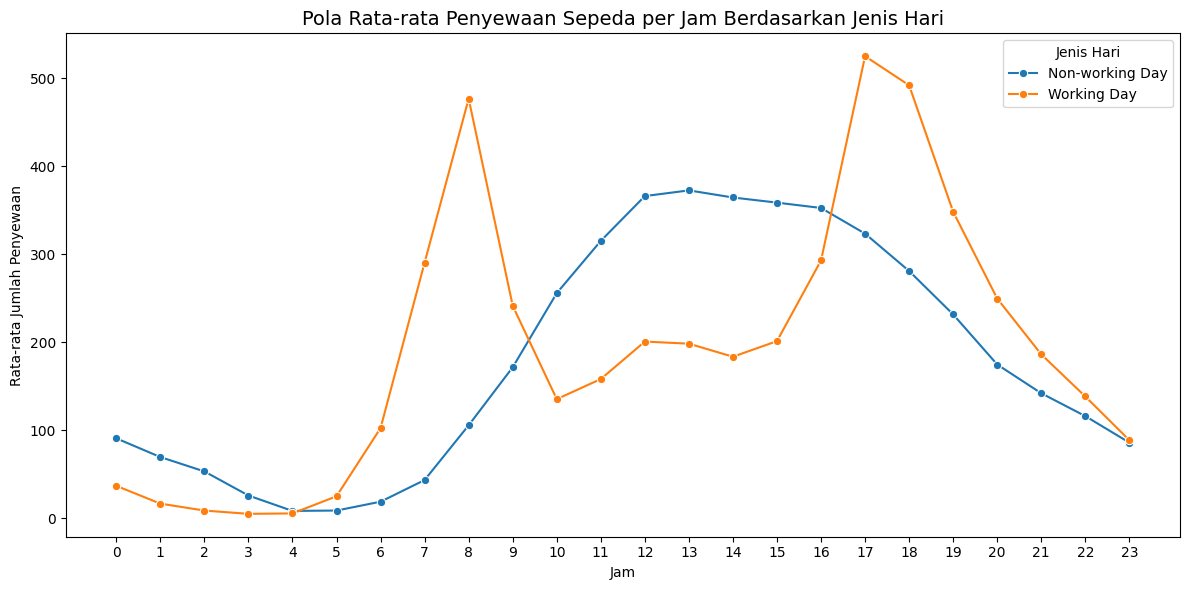

In [ ]:
#Visualisasi Pola Penyewaan per Jam
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_analysis,
    x="hr",
    y="cnt",
    hue="workingday_name",
    marker="o"
)

plt.title("Pola Rata-rata Penyewaan Sepeda per Jam Berdasarkan Jenis Hari", fontsize=14)
plt.xlabel("Jam")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(range(0, 24))
plt.legend(title="Jenis Hari")
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Visualisasi menunjukkan bahwa pola penyewaan pada hari kerja memiliki dua puncak utama, yaitu pagi hari dan sore hari. Hal ini mengindikasikan penggunaan sepeda untuk aktivitas commuting. Sementara itu, pada hari non-kerja, penyewaan lebih tinggi pada siang hingga sore hari, yang kemungkinan berkaitan dengan aktivitas santai atau rekreasi.

## Analisis Lanjutan (Opsional)

## Analisis Lanjutan: Pengelompokan Tingkat Permintaan

Pada tahap ini, dilakukan manual grouping atau binning untuk mengelompokkan tingkat permintaan penyewaan sepeda berdasarkan jumlah `cnt`. Teknik ini bertujuan untuk membantu operasional dalam menentukan prioritas ketersediaan sepeda.

In [ ]:
def demand_category(cnt):
    if cnt < 2000:
        return "Low Demand"
    elif cnt < 5000:
        return "Medium Demand"
    else:
        return "High Demand"

day_df["demand_category"] = day_df["cnt"].apply(demand_category)

day_df[["dteday", "cnt", "demand_category"]].head()

,dteday,cnt,demand_category
0,2011-01-01,985,Low Demand
1,2011-01-02,801,Low Demand
2,2011-01-03,1349,Low Demand
3,2011-01-04,1562,Low Demand
4,2011-01-05,1600,Low Demand


In [ ]:
demand_summary = day_df.groupby("demand_category").agg({
    "instant": "count",
    "cnt": "mean"
}).rename(columns={
    "instant": "total_days",
    "cnt": "avg_rentals"
}).reset_index()

demand_summary

,demand_category,total_days,avg_rentals
0,High Demand,286,6457.076923
1,Low Demand,98,1394.775510
2,Medium Demand,347,3773.103746


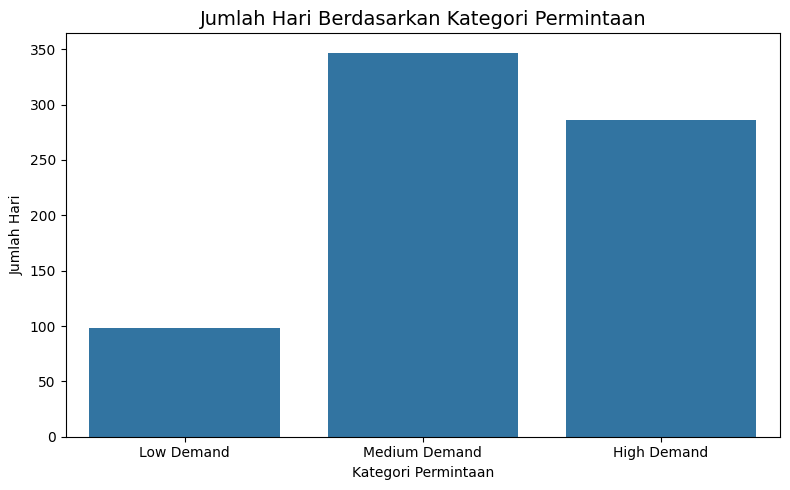

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=demand_summary,
    x="demand_category",
    y="total_days",
    order=["Low Demand", "Medium Demand", "High Demand"]
)

plt.title("Jumlah Hari Berdasarkan Kategori Permintaan", fontsize=14)
plt.xlabel("Kategori Permintaan")
plt.ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

Pengelompokan ini membantu perusahaan memahami berapa banyak hari yang masuk ke kategori permintaan rendah, sedang, dan tinggi. Hasil ini dapat digunakan untuk membuat strategi operasional, misalnya menambah ketersediaan sepeda saat potensi permintaan tinggi dan mengurangi distribusi sepeda saat permintaan rendah.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis, musim Fall memiliki rata-rata penyewaan sepeda harian tertinggi, yaitu sekitar 5.644 penyewaan per hari. Sebaliknya, musim Spring memiliki rata-rata penyewaan terendah, yaitu sekitar 2.604 penyewaan per hari. Dari sisi cuaca, kondisi Clear/Partly Cloudy menghasilkan rata-rata penyewaan tertinggi, sedangkan Light Snow/Rain menghasilkan rata-rata penyewaan terendah.
- **Conclusion pertanyaan 2:** Pola penyewaan sepeda berbeda antara hari kerja dan hari non-kerja. Pada hari kerja, permintaan tertinggi terjadi pada jam berangkat dan pulang kerja, terutama sekitar pukul 08.00, 17.00, dan 18.00. Pada hari non-kerja, permintaan lebih tinggi pada siang hingga sore hari, sekitar pukul 12.00–16.00.
- ...

**Rekomendasi Action Item:**
- Perusahaan sebaiknya menambah ketersediaan sepeda pada musim Fall dan saat cuaca cerah karena permintaan cenderung lebih tinggi.
- Pada hari kerja, sepeda perlu lebih banyak tersedia pada pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00–18.00.
- Pada hari non-kerja, distribusi sepeda dapat difokuskan pada siang hingga sore hari karena pola penggunaan lebih mengarah pada aktivitas rekreasi.
- Saat cuaca buruk seperti Light Snow/Rain, perusahaan dapat mengurangi distribusi sepeda di beberapa titik dan mengalihkan fokus pada perawatan armada atau promosi khusus.